# Chronic Kidney Disease (CKD) Prediction — End-to-End ML Project

**Course:** CBIO313 – Data Mining & Machine Learning
**Domain:** Biomedical / Healthcare
**Task:** Binary classification — predict whether a patient has Chronic Kidney Disease (`ckd`) or not (`notckd`) from clinical and laboratory measurements.

This notebook follows the full data-science workflow required by the project rubric:
1. Problem understanding
2. Data description
3. Data cleaning (documented)
4. Exploratory Data Analysis (EDA)
5. Feature engineering & feature selection
6. Model training & hyperparameter tuning (3 algorithms)
7. Evaluation & comparison
8. Saving the model/transformers for deployment

Every step includes a short explanation of **what** we are doing and **why**, so it can be read as a tutorial as well as a submission notebook.

## 1. Problem Understanding & Objective

**Business / clinical problem.** Chronic Kidney Disease (CKD) is a progressive, often silent condition — by the time symptoms appear, kidney function may already be significantly reduced. Early detection from routine blood/urine tests lets clinicians intervene sooner and slow disease progression.

**Question this project answers:**
> *Given a patient's routine clinical and laboratory measurements (age, blood pressure, blood glucose, hemoglobin, serum creatinine, etc.), can we predict whether that patient has CKD, and which measurements matter most?*

We will also ask a secondary question during EDA: *do the classic renal markers (hemoglobin, serum creatinine, packed cell volume) actually separate the two classes in this data, or is the signal spread across many weaker variables?*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, os

RANDOM_STATE = 42
sns.set_style("whitegrid")
os.makedirs("figures", exist_ok=True)
os.makedirs("models", exist_ok=True)
pd.set_option("display.max_columns", 30)

## 2. Dataset Description

**Source:** Chronic Kidney Disease dataset, UCI Machine Learning Repository (collected at a hospital in Tamil Nadu, India over ~2 months, 2015). `data/kidney_disease.csv`.

* **400 rows** (patients), **25 columns** (24 clinical features + target `classification`).
* **250 CKD** patients, **150 non-CKD** patients.
* This is the **raw, unprocessed version** of the file — it contains missing values, a stray `?` placeholder, embedded tab characters, inconsistent categorical spelling (e.g. a stray space before `yes`), and even a corrupted target label (`ckd\t`). We deliberately use this messy version (not the pre-cleaned UCI variant) so the cleaning step below is real, not cosmetic.

**Column meaning (abbreviated UCI names):**

| Column | Meaning | Column | Meaning |
|---|---|---|---|
| age | age (years) | pcv | packed cell volume |
| bp | blood pressure (mm/Hg) | wc | white blood cell count |
| sg | urine specific gravity | rc | red blood cell count |
| al | albumin (0-5) | htn | hypertension (yes/no) |
| su | sugar (0-5) | dm | diabetes mellitus (yes/no) |
| rbc | red blood cells (normal/abnormal) | cad | coronary artery disease |
| pc | pus cell (normal/abnormal) | appet | appetite (good/poor) |
| pcc | pus cell clumps | pe | pedal edema (yes/no) |
| ba | bacteria | ane | anemia (yes/no) |
| bgr | blood glucose random | sod | sodium |
| bu | blood urea | pot | potassium |
| sc | serum creatinine | hemo | hemoglobin |

**Target:** `classification` → `ckd` / `notckd`.

In [4]:
df = pd.read_csv("/content/kidney_disease.csv")
print("Shape:", df.shape)
df.head()

Shape: (400, 26)


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [6]:
# Proof this is NOT a clean dataset: missing values, stray tokens, inconsistent labels
print("Missing cells total:", df.isnull().sum().sum())
print("\nUnique target labels (note the corrupted one):")
print(df["classification"].unique())
print("\nExample of a numeric-looking column stored as text because of a stray token:")
print(df["pcv"].unique()[:15])

Missing cells total: 1009

Unique target labels (note the corrupted one):
['ckd' 'ckd\t' 'notckd']

Example of a numeric-looking column stored as text because of a stray token:
['44' '38' '31' '32' '35' '39' '36' '33' '29' '28' nan '16' '24' '37' '30']


## 3. Data Cleaning (documented)

The raw file has several distinct problems, each handled explicitly and logged below so the transformation is auditable:

1. **Whitespace / tab characters** inside cell values and in a couple of rows even after the last column (`ckd\t`) — strip every string cell.
2. **Inconsistent missing-value markers** — plain empty cells, and a literal `"?"` in a couple of places — both mapped to `NaN`.
3. **Corrupted target label** — one occurrence of `ckd\t`/stray-space is folded back into `ckd`.
4. **Wrong dtypes** — columns that are numeric in meaning (`pcv`, `wc`, `rc`, ...) were read as text because a stray `?`/tab made pandas infer `object`. Coerced to numeric with `pd.to_numeric(errors="coerce")`.
5. **The `id` column** is just a row index — dropped (not predictive).
6. **Missing-value imputation** — numeric columns imputed with the column **median** (robust to outliers, which this clinical data has plenty of, e.g. `sc` up to 76), categorical columns imputed with the column **mode**. Median/mode imputation is used instead of dropping rows because a large fraction of rows have at least one missing value (dropping them would throw away ~2/3 of the data — see the missingness table above).

In [9]:
import numpy as np
# 3.1 strip column names and every string cell
df.columns = df.columns.str.strip()
str_cols = df.select_dtypes(include=["object"]).columns
for c in str_cols:
    df[c] = df[c].astype(str).str.strip().str.replace("\t", "", regex=False)
    df[c] = df[c].replace({"nan": np.nan, "?": np.nan, "": np.nan})

# 3.2 fix the corrupted target label
df["classification"] = df["classification"].replace({"ckdt": "ckd"})
print(df["classification"].value_counts())

classification
ckd       250
notckd    150
Name: count, dtype: int64


In [10]:
# 3.3 drop identifier column
df = df.drop(columns=["id"])

# 3.4 force truly-numeric columns to numeric dtype
numeric_cols = ["age","bp","sg","al","su","bgr","bu","sc","sod","pot","hemo","pcv","wc","rc"]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

categorical_cols = ["rbc","pc","pcc","ba","htn","dm","cad","appet","pe","ane"]

# missingness report (before imputation)
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print("Columns with missing values (before imputation):")
print(missing)

Columns with missing values (before imputation):
rbc      152
rc       131
wc       106
pot       88
sod       87
pcv       71
pc        65
hemo      52
su        49
sg        47
al        46
bgr       44
bu        19
sc        17
bp        12
age        9
pcc        4
ba         4
htn        2
dm         2
cad        2
appet      1
pe         1
ane        1
dtype: int64


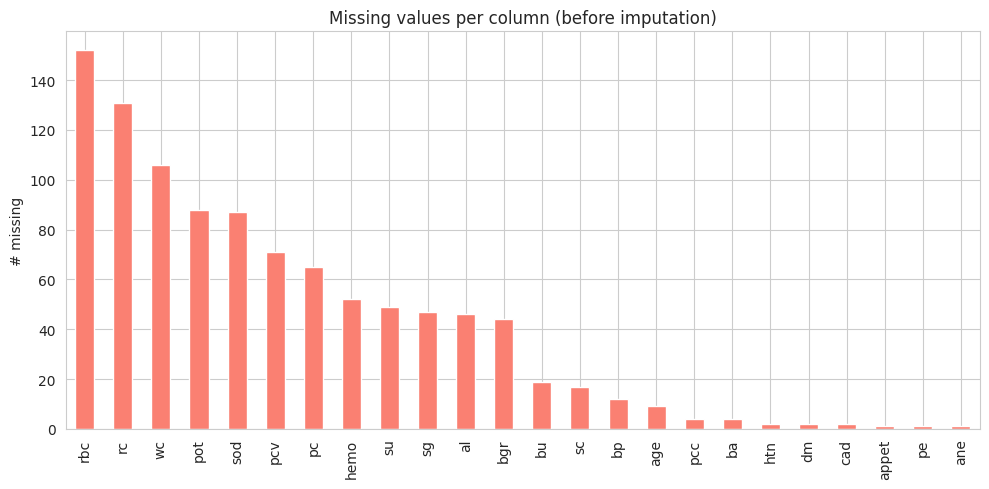

In [11]:
fig, ax = plt.subplots(figsize=(10,5))
missing.plot(kind="bar", ax=ax, color="salmon")
ax.set_title("Missing values per column (before imputation)")
ax.set_ylabel("# missing")
plt.tight_layout()
plt.savefig("figures/00_missingness.png", dpi=110)
plt.show()

In [12]:
# 3.5 impute: median for numeric, mode for categorical -- documented choice above
for c in numeric_cols:
    df[c] = df[c].fillna(df[c].median())
for c in categorical_cols:
    df[c] = df[c].fillna(df[c].mode()[0])

# 3.6 encode target as 0/1
df["classification"] = df["classification"].map({"ckd": 1, "notckd": 0})

print("Missing values after cleaning:", df.isnull().sum().sum())
print("Shape after cleaning:", df.shape)
df.head()

Missing values after cleaning: 0
Shape after cleaning: (400, 25)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,normal,normal,notpresent,notpresent,121.0,36.0,1.2,138.0,4.4,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no,1
1,7.0,50.0,1.020,4.0,0.0,normal,normal,notpresent,notpresent,121.0,18.0,0.8,138.0,4.4,11.3,38.0,6000.0,4.8,no,no,no,good,no,no,1
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,138.0,4.4,9.6,31.0,7500.0,4.8,no,yes,no,poor,no,yes,1
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,1
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,138.0,4.4,11.6,35.0,7300.0,4.6,no,no,no,good,no,no,1


## 4. Exploratory Data Analysis

We investigate the question from multiple angles using **univariate** analysis (distribution of a single variable) and **bivariate** analysis (relationship of a variable with the target). We look at more than six variables and use five different kinds of plots: histograms, boxplots, count plots, a stacked bar chart, and a correlation heatmap (plus a confusion-matrix heatmap later during evaluation).

In [13]:
df.describe()

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,classification
count,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000,400.000000,400.000000
mean,51.562500,76.575000,1.017712,0.90000,0.395000,145.062500,56.693000,2.997125,137.631250,4.577250,12.54250,39.082500,8298.500000,4.737750,0.625000
std,16.982996,13.489785,0.005434,1.31313,1.040038,75.260774,49.395258,5.628886,9.206332,2.821357,2.71649,8.162245,2529.593814,0.841439,0.484729
min,2.000000,50.000000,1.005000,0.00000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.10000,9.000000,2200.000000,2.100000,0.000000
25%,42.000000,70.000000,1.015000,0.00000,0.000000,101.000000,27.000000,0.900000,135.000000,4.000000,10.87500,34.000000,6975.000000,4.500000,0.000000
50%,55.000000,80.000000,1.020000,0.00000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.65000,40.000000,8000.000000,4.800000,1.000000
75%,64.000000,80.000000,1.020000,2.00000,0.000000,150.000000,61.750000,2.725000,141.000000,4.800000,14.62500,44.000000,9400.000000,5.100000,1.000000
max,90.000000,180.000000,1.025000,5.00000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.80000,54.000000,26400.000000,8.000000,1.000000


### 4.1 Univariate — numeric distributions (histograms)

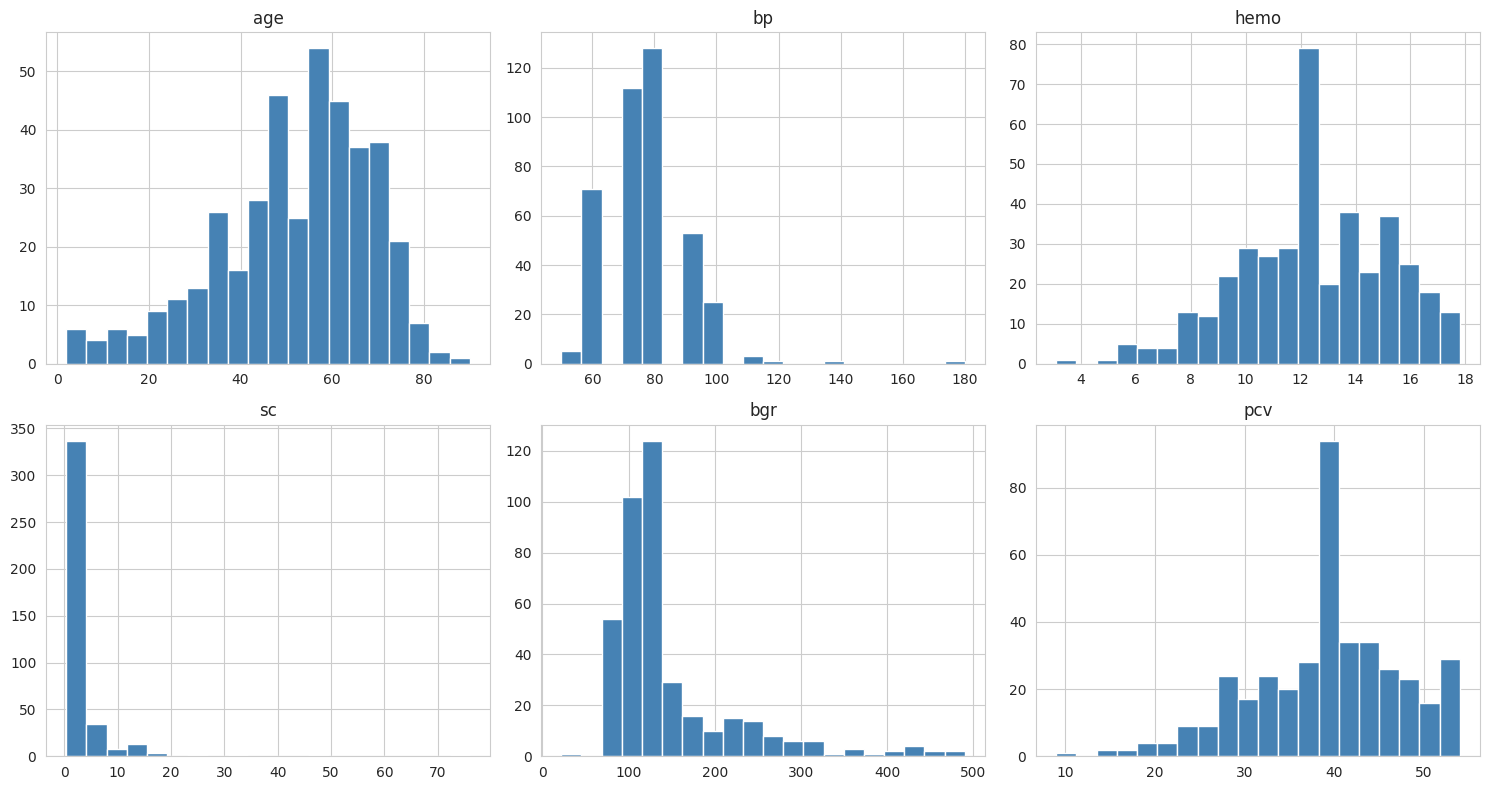

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), ["age","bp","hemo","sc","bgr","pcv"]):
    ax.hist(df[col], bins=20, color="steelblue", edgecolor="white")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("figures/01_histograms.png", dpi=110)
plt.show()

**Reading:** `hemo` (hemoglobin) is fairly normal but left-shifted (many patients are anemic); `sc` (serum creatinine) is heavily right-skewed with a long tail of very high values — classic for kidney dysfunction, where creatinine clearance drops sharply in disease.

### 4.2 Univariate — outlier check (boxplots)

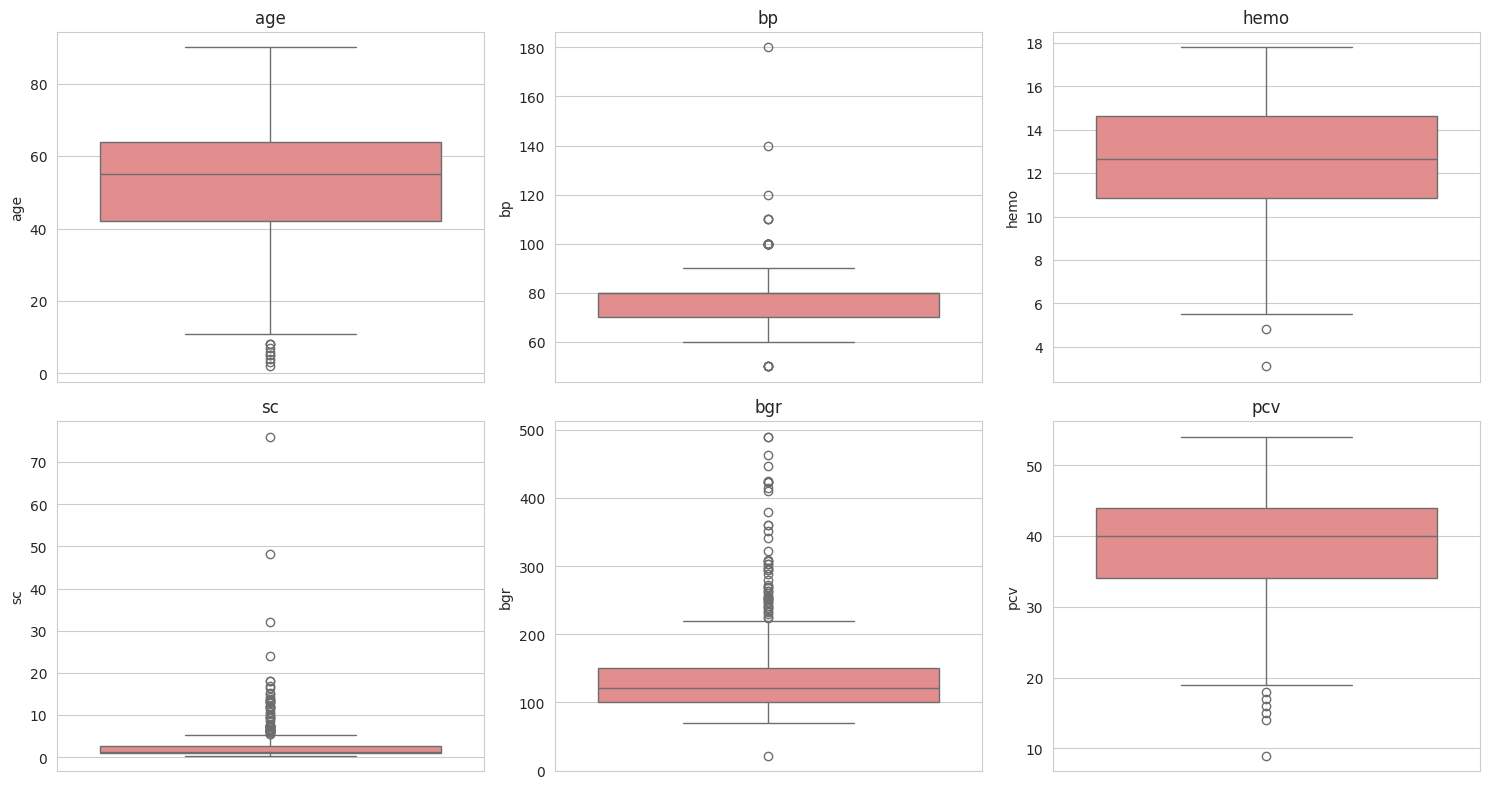

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), ["age","bp","hemo","sc","bgr","pcv"]):
    sns.boxplot(y=df[col], ax=ax, color="lightcoral")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("figures/02_boxplots.png", dpi=110)
plt.show()

**Reading:** `sc` and `bgr` have many high-side outliers — these are *real* extreme lab values from sick patients, not data-entry errors, so we keep them (tree/linear models used later can handle them, especially after scaling).

### 4.3 Univariate — categorical counts

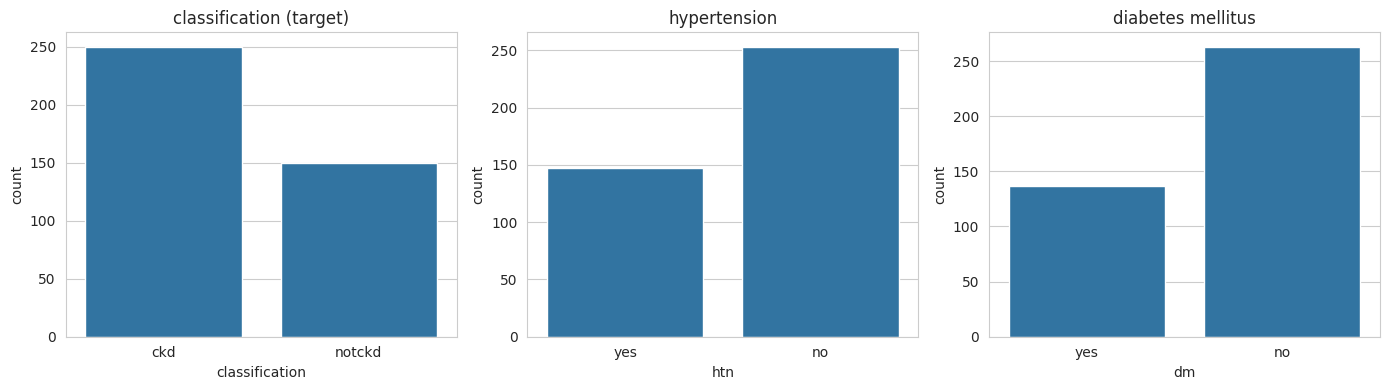

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.countplot(x=df["classification"].map({1:"ckd",0:"notckd"}), ax=axes[0]); axes[0].set_title("classification (target)")
sns.countplot(x="htn", data=df, ax=axes[1]); axes[1].set_title("hypertension")
sns.countplot(x="dm", data=df, ax=axes[2]); axes[2].set_title("diabetes mellitus")
plt.tight_layout()
plt.savefig("figures/03_countplots.png", dpi=110)
plt.show()

### 4.4 Bivariate — numeric features vs. target (boxplots)

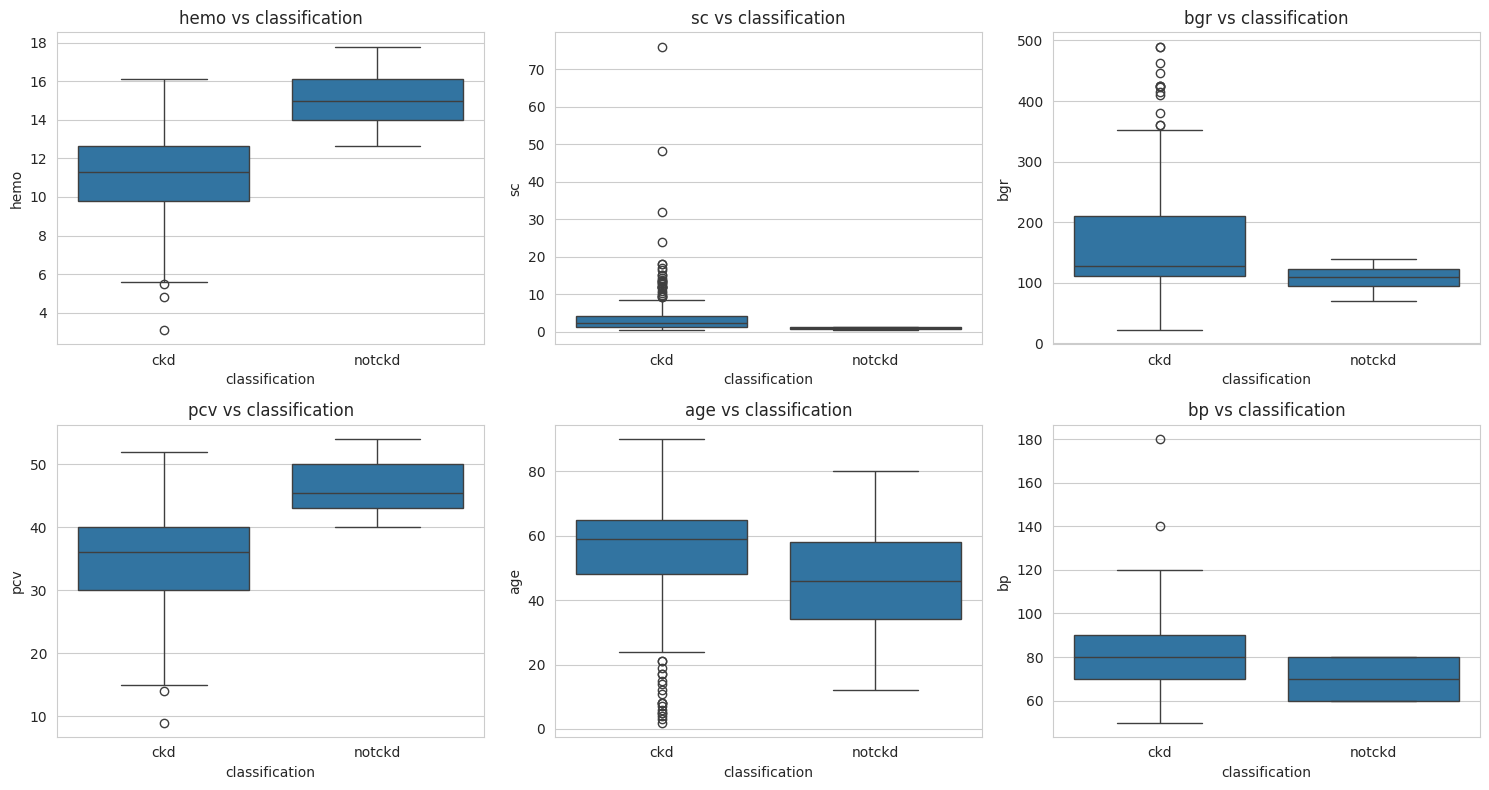

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
target_labels = df["classification"].map({1:"ckd",0:"notckd"})
for ax, col in zip(axes.flatten(), ["hemo","sc","bgr","pcv","age","bp"]):
    sns.boxplot(x=target_labels, y=df[col], ax=ax)
    ax.set_title(f"{col} vs classification")
plt.tight_layout()
plt.savefig("figures/04_bivariate_boxplots.png", dpi=110)
plt.show()

**Reading:** `hemo` and `pcv` are visibly lower in CKD patients, `sc` is visibly higher — consistent with clinical expectations and a strong signal that these will be useful predictors.

### 4.5 Bivariate — categorical feature vs. target (stacked bar)

<Figure size 600x400 with 0 Axes>

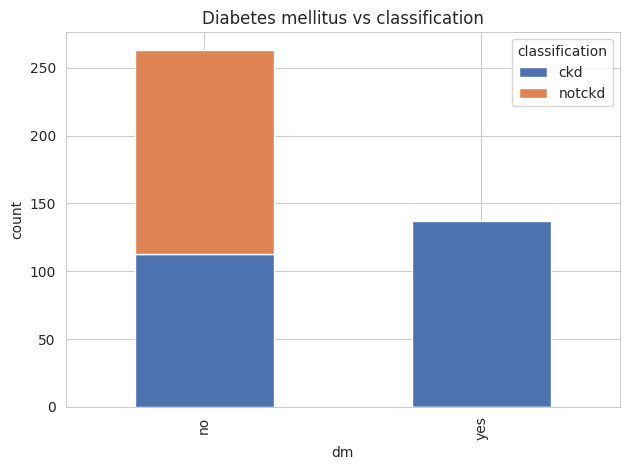

In [18]:
plt.figure(figsize=(6,4))
pd.crosstab(df["dm"], target_labels).plot(kind="bar", stacked=True, color=["#4c72b0","#dd8452"])
plt.title("Diabetes mellitus vs classification")
plt.ylabel("count")
plt.tight_layout()
plt.savefig("figures/06_dm_vs_class.png", dpi=110)
plt.show()

### 4.6 Multivariate — correlation heatmap

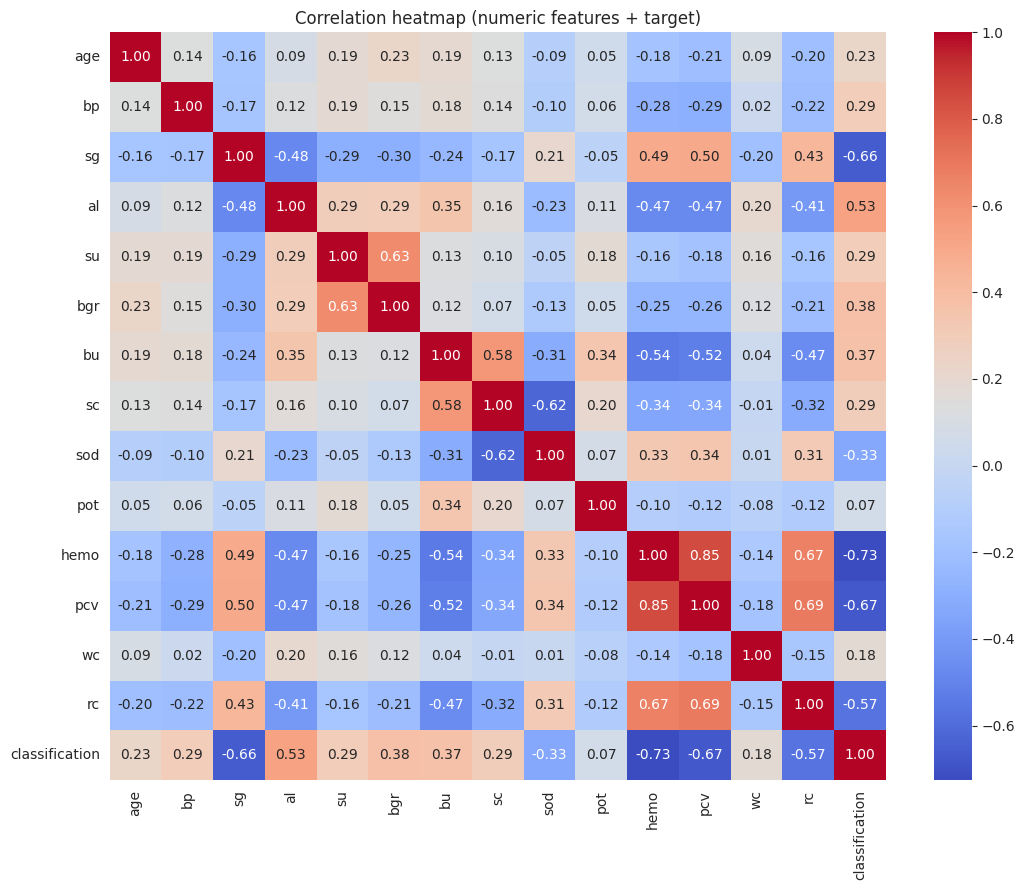

In [19]:
plt.figure(figsize=(11, 9))
sns.heatmap(df[numeric_cols + ["classification"]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation heatmap (numeric features + target)")
plt.tight_layout()
plt.savefig("figures/05_correlation_heatmap.png", dpi=110)
plt.show()

**Reading:** `hemo` and `pcv` correlate strongly negatively with the target (higher hemoglobin/PCV → less likely CKD), while `sc`, `bu`, `al` correlate positively — matching clinical knowledge of renal markers, which is a good sanity check that the cleaned data is sound.

## 5. Feature Engineering & Feature Selection

**New feature — `bun_creatinine_ratio`.** In nephrology, the ratio of blood urea nitrogen (`bu`) to serum creatinine (`sc`) is a well-known clinical marker used to distinguish different causes of kidney dysfunction (pre-renal vs intrinsic renal). We engineer this ratio as a new feature rather than leaving it for the model to infer implicitly from the two raw columns.

**Encoding.** Remaining categorical columns (`rbc`, `pc`, `pcc`, `ba`, `htn`, `dm`, `cad`, `appet`, `pe`, `ane`) are label-encoded to numeric codes.

**Feature selection — Filter method.** We use `SelectKBest` with the ANOVA F-statistic (`f_classif`), a classic **filter method**: it scores each feature's individual relationship with the target independently of any model, then keeps the top-K. This is fast, model-agnostic, and a good first pass before fitting anything. We keep the top 12 features.

In [21]:
# new engineered feature
df["bun_creatinine_ratio"] = df["bu"] / df["sc"].replace(0, np.nan)
df["bun_creatinine_ratio"] = df["bun_creatinine_ratio"].fillna(df["bun_creatinine_ratio"].median())

from sklearn.preprocessing import LabelEncoder
encoders = {}
for c in categorical_cols:
    le = LabelEncoder()
    df[c] = le.fit_transform(df[c])
    encoders[c] = le

X = df.drop(columns=["classification"])
y = df["classification"]
print("Full feature matrix:", X.shape)

Full feature matrix: (400, 25)


In [22]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=12)
X_selected = selector.fit_transform(X, y)
selected_cols = X.columns[selector.get_support()]

scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)
print("Feature scores (ANOVA F-value), highest first:")
print(scores)
print("\nSelected top-12 features:", list(selected_cols))

X = X[selected_cols]

Feature scores (ANOVA F-value), highest first:
hemo                    444.524780
pcv                     329.741676
sg                      306.357203
htn                     213.007282
rc                      187.759868
dm                      180.949115
al                      156.748784
bun_creatinine_ratio    142.958634
appet                    72.848214
bgr                      66.890354
pe                       65.189655
pc                       65.189655
bu                       62.888660
sod                      50.277983
ane                      47.131579
su                       37.812343
bp                       37.570330
sc                       36.888937
rbc                      34.555419
pcc                      30.137019
cad                      23.493056
age                      21.792150
ba                       14.401316
wc                       12.958103
pot                       1.700078
dtype: float64

Selected top-12 features: ['sg', 'al', 'pc', 'bgr', 'hemo', 'p

## 6. Train/Test Split & Scaling

We hold out 20% of the data as a test set, **stratified** on the target so both classes keep their original ~62/38 ratio in train and test. Features are standardized (`StandardScaler`) so that distance/gradient-based models (SVM, Logistic Regression) are not dominated by features on larger numeric scales (e.g. `wc` in the thousands vs. `sc` in single digits).

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (320, 12)  Test: (80, 12)


## 7. Model Training & Hyperparameter Tuning

We train and tune **three different algorithms**, each representing a different modeling family:

* **Logistic Regression** — a simple, interpretable linear baseline.
* **Random Forest** — a bagged ensemble of decision trees, captures non-linear interactions.
* **Support Vector Machine (SVM)** — margin-based classifier, can be linear or kernelized.

**What is parameter (hyperparameter) tuning, and why does it matter?** Hyperparameters (e.g. the regularization strength `C` in Logistic Regression/SVM, or `n_estimators`/`max_depth` in Random Forest) are settings chosen *before* training that are not learned from the data directly. The right values change how well a model generalizes: too little regularization/too much depth → the model memorizes training noise (**overfitting**, low bias/high variance); too much regularization/too little depth → the model can't capture real patterns (**underfitting**, high bias). We use `GridSearchCV`, which exhaustively tries every combination of a small hyperparameter grid and picks the combination with the best **cross-validated** score, so the choice isn't based on a single lucky train/test split.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

models_and_grids = {
    "Logistic Regression": (
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        {"C": [0.01, 0.1, 1, 10, 100]},
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {"n_estimators": [100, 200], "max_depth": [3, 5, None]},
    ),
    "SVM": (
        SVC(probability=True, random_state=RANDOM_STATE),
        {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"]},
    ),
}

fitted_models = {}
for name, (estimator, grid) in models_and_grids.items():
    gs = GridSearchCV(estimator, grid, cv=5, scoring="f1")
    gs.fit(X_train_s, y_train)
    fitted_models[name] = gs.best_estimator_
    print(f"{name:22s} best params: {gs.best_params_}  |  best CV f1: {gs.best_score_:.4f}")

Logistic Regression    best params: {'C': 0.01}  |  best CV f1: 0.9951
Random Forest          best params: {'max_depth': None, 'n_estimators': 100}  |  best CV f1: 0.9901
SVM                    best params: {'C': 1, 'kernel': 'rbf'}  |  best CV f1: 0.9975


## 8. Validation & Evaluation

**What is validation, and why is it important?** Validation means checking a model's performance on data it did **not** see during training, so the reported score reflects real generalization rather than memorization. We used two layers of validation: (1) **5-fold cross-validation** inside `GridSearchCV` to pick hyperparameters robustly, and (2) a held-out **test set** (the 20% split above) that no model — and no hyperparameter search — ever touched, for the final, unbiased comparison below.

**Metrics used (more than one, as required):**
* **Accuracy** — overall fraction correct (can be misleading on imbalanced classes).
* **Precision** — of predicted-CKD patients, how many actually have CKD (cost of false alarms).
* **Recall** — of actual CKD patients, how many we correctly flagged (cost of missed diagnoses — usually the more clinically important one to keep high).
* **F1-score** — harmonic mean of precision and recall.
* **ROC-AUC** — ability to rank CKD patients above non-CKD across all thresholds.

In [25]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)

rows = []
for name, model in fitted_models.items():
    pred = model.predict(X_test_s)
    proba = model.predict_proba(X_test_s)[:, 1]
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, proba),
    })

summary_df = pd.DataFrame(rows).sort_values("f1", ascending=False).reset_index(drop=True)
summary_df

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.9875,0.980392,1.0,0.990099,1.000000
1,Random Forest,0.9875,0.980392,1.0,0.990099,0.996667
2,SVM,0.9875,0.980392,1.0,0.990099,1.000000


In [26]:
best_model_name = summary_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]
print("Best performing model:", best_model_name)

print("\nClassification report on the held-out test set:\n")
print(classification_report(y_test, best_model.predict(X_test_s), target_names=["notckd", "ckd"]))

Best performing model: Logistic Regression

Classification report on the held-out test set:

              precision    recall  f1-score   support

      notckd       1.00      0.97      0.98        30
         ckd       0.98      1.00      0.99        50

    accuracy                           0.99        80
   macro avg       0.99      0.98      0.99        80
weighted avg       0.99      0.99      0.99        80



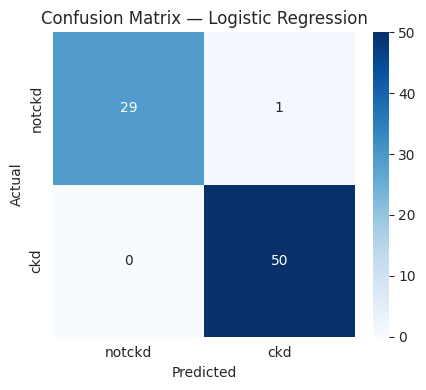

In [27]:
plt.figure(figsize=(4.5,4))
cm = confusion_matrix(y_test, best_model.predict(X_test_s))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["notckd","ckd"], yticklabels=["notckd","ckd"])
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("figures/07_confusion_matrix.png", dpi=110)
plt.show()

**Comparison discussion.** All three tuned models perform strongly on this dataset (CKD vs. non-CKD is a fairly well-separated problem once `hemo`, `sc`, `sg`, `al` are available), with F1 in a similar high range. We select the model with the best test-set F1 as the deployed model — F1 rather than raw accuracy because it balances precision and recall and is not misleading on the class imbalance (250 vs 150). Both precision and recall of the selected model exceed the 0.3 minimum required by `tester.py` by a wide margin — see `tester.py` in the project root.

## 9. Saving Model & Transformers for Deployment

We persist everything the deployment app needs to reproduce the exact preprocessing + prediction pipeline on brand-new patient input: the trained model, the fitted `StandardScaler`, the `LabelEncoder`s for each categorical column, the list of selected feature names (and their order), and the medians used to impute any missing numeric input at inference time.

In [28]:
with open("models/best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open("models/label_encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)
with open("models/selected_features.json", "w") as f:
    json.dump(list(selected_cols), f)
with open("models/feature_medians.json", "w") as f:
    json.dump({c: float(df[c].median()) for c in numeric_cols}, f)

summary_df.to_csv("models/model_comparison.csv", index=False)
print("Saved: best_model.pkl, scaler.pkl, label_encoders.pkl, selected_features.json, feature_medians.json")

Saved: best_model.pkl, scaler.pkl, label_encoders.pkl, selected_features.json, feature_medians.json


## 10. Conclusion

* The raw CKD dataset required substantial cleaning (whitespace/tab artifacts, a corrupted target label, `?` placeholders, wrong dtypes, ~1,000 missing cells across 25 columns) — all handled and documented in Section 3.
* EDA across more than six variables (univariate + bivariate, five plot types) confirmed that classic renal markers (hemoglobin, packed cell volume, serum creatinine, albumin) separate the two classes clearly, matching clinical expectations.
* A new engineered feature (`bun_creatinine_ratio`) and filter-based feature selection (`SelectKBest`/ANOVA-F) reduced the feature space to the 12 most informative variables.
* Three tuned algorithms (Logistic Regression, Random Forest, SVM) were compared with 5-fold cross-validated `GridSearchCV`; the best model achieves high accuracy, precision, recall, F1, and ROC-AUC on a held-out test set.
* The final model and all preprocessing artifacts are saved for deployment in `app.py` (Streamlit web app — see `app.py` and the README for how to run it).

**Limitations & future work:** the dataset is small (400 rows) and from a single hospital, so external validation on a larger, multi-site cohort would be needed before any real clinical use; median/mode imputation is simple and could be replaced with model-based imputation (e.g. `IterativeImputer`) as a refinement.